# CostGrow PCRaster Inline

Small proof-of-concept notebook for the `2407_FHIMP_tile` sample.

## Outline
- Step 00: imports and fixed parameters
- Step 01: load the hard-coded tile inputs
- Step 02: build coarse WSE and resample it to the fine grid
- Step 03: grow depth with PCRaster-only spread operations
- Step 04: review a few simple inline plots


In [7]:
%matplotlib inline

# Step 00: imports and fixed parameters.
# This notebook is intentionally rigid: one tile, one parameter set, no fallbacks.

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pcraster as pcr
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import reproject

TILE_DIR = Path("/home/cefect/LS/09_REPOS/04_TOOLS/floodsr/tests/data/rss_dudelange_A")
LOWRES_DEPTH_FP = TILE_DIR / "lowres030.tif"
DEM_FP = TILE_DIR / "hires003_dem.tif"

DP_COARSE_PIXEL_MAX = 10
DECAY_FRAC = 0.001

FIGSIZE = (14, 9)
DEPTH_CMAP = "viridis"
DEM_CMAP = "terrain"

print(f" input depth: {LOWRES_DEPTH_FP.name}")
print(f" input dem: {DEM_FP.name}")
print(f"numpy: {np.__version__}")
print(f"rasterio: {rasterio.__version__}")
print(f"matplotlib: {plt.matplotlib.__version__}")


 input depth: lowres030.tif
 input dem: hires003_dem.tif
numpy: 2.4.2
rasterio: 1.5.0
matplotlib: 3.10.8


## Step 01
Load the fixed chip inputs and convert nodata to `NaN`.


In [8]:
# Step 01: load the fine DEM and coarse depth.
# The tile stores depth, not WSE, so the notebook derives WSE in the next step.

with rasterio.open(DEM_FP) as ds:
    dem = ds.read(1).astype("float64")
    dem[dem == ds.nodata] = np.nan
    dem_transform = ds.transform
    dem_crs = ds.crs
    dem_bounds = ds.bounds
    dem_res = abs(ds.res[0])
    dem_shape = dem.shape

with rasterio.open(LOWRES_DEPTH_FP) as ds:
    coarse_depth = ds.read(1).astype("float64")
    coarse_depth[coarse_depth == ds.nodata] = np.nan
    coarse_transform = ds.transform
    coarse_crs = ds.crs
    coarse_shape = (ds.height, ds.width)
    coarse_res = abs(ds.res[0])

assert dem_crs == coarse_crs

print(f"coarse shape: {coarse_shape}, res: {coarse_res:.1f} m")
print(f"fine shape: {dem_shape}, res: {dem_res:.1f} m")
print(f"coarse depth range: {np.nanmin(coarse_depth):.3f} to {np.nanmax(coarse_depth):.3f} m")
print(f"dem range: {np.nanmin(dem):.3f} to {np.nanmax(dem):.3f} m")


coarse shape: (203, 209), res: 30.0 m
fine shape: (2030, 2090), res: 3.0 m
coarse depth range: 0.000 to 4.598 m
dem range: 226.200 to 434.170 m


## Step 02
Build coarse WSE from coarse depth plus coarse DEM, then resample onto the fine DEM grid.


In [9]:
# Step 02: derive coarse WSE and move it to the fine grid with rasterio.
# Averaging the DEM down first keeps the coarse WSE consistent with the input depth product.

coarse_dem = np.full(coarse_shape, np.nan, dtype="float64")

reproject(
    dem,
    coarse_dem,
    src_transform=dem_transform,
    src_crs=dem_crs,
    src_nodata=np.nan,
    dst_transform=coarse_transform,
    dst_crs=coarse_crs,
    dst_nodata=np.nan,
    resampling=Resampling.average,
)

coarse_wse = coarse_dem + coarse_depth

fine_wse = np.full(dem_shape, np.nan, dtype="float64")

reproject(
    coarse_wse,
    fine_wse,
    src_transform=coarse_transform,
    src_crs=coarse_crs,
    src_nodata=np.nan,
    dst_transform=dem_transform,
    dst_crs=dem_crs,
    dst_nodata=np.nan,
    resampling=Resampling.bilinear,
)

# Keep only the fine-grid cells that are already wet after the simple resample.
# This wet-only resampled depth field is the notebook's "pre-processed depths" layer.
# In other words: it is the initial fine-grid depth field before any PCRaster growth logic is applied.
seed_wse = np.where(fine_wse > dem, fine_wse, np.nan)
seed_depth = np.where(np.isfinite(seed_wse), seed_wse - dem, np.nan)

print(f"pre-processed wet cells: {int(np.isfinite(seed_depth).sum()):,}")
print(f"pre-processed depth range: {np.nanmin(seed_depth):.3f} to {np.nanmax(seed_depth):.3f} m")


pre-processed wet cells: 2,229,663
pre-processed depth range: 0.000 to 13.118 m


## Step 03
Use PCRaster for both nearest-source allocation and terrain-aware growth. No `xarray`, `scipy`, or `scikit-image`.


In [10]:
# Step 03A: initialize the PCRaster clone and source ids.
# Every wet pre-processed cell gets a unique id so spreadzone can map grown cells back to a source WSE value.

rows, cols = dem_shape
pcr.setclone(rows, cols, dem_res, dem_bounds.left, dem_bounds.top)

seed_mask = np.isfinite(seed_wse)
assert seed_mask.any()

source_ids = np.full(dem_shape, -9999, dtype=np.int32)
source_ids[seed_mask] = np.arange(1, seed_mask.sum() + 1, dtype=np.int32)
source_map = pcr.numpy2pcr(pcr.Nominal, source_ids, -9999)

lookup = np.full(seed_mask.sum() + 1, np.nan, dtype="float64")
lookup[1:] = seed_wse[seed_mask]

# Step 03B: nearest-source fill on a uniform friction surface.
# This replaces the old scipy nearest-neighbor distance transform logic.

uniform_cost = np.where(np.isfinite(dem), 1.0, -9999.0).astype("float32")
uniform_cost_map = pcr.numpy2pcr(pcr.Scalar, uniform_cost, -9999)

nearest_zone = pcr.pcr2numpy(pcr.spreadzone(source_map, 0, uniform_cost_map), 0)
distance_cells = pcr.pcr2numpy(pcr.spread(source_map, 0, uniform_cost_map), -9999.0)
distance_m = distance_cells * dem_res
nearest_wse = lookup[nearest_zone]

# Step 03C: build a terrain penalty from the nearest-source WSE.
# Cells below the nearest-source WSE get cheap travel cost; uphill cells get penalized.

terrain_cost = np.where(
    np.isfinite(nearest_wse),
    np.where(nearest_wse > dem, 1.0, 1.0 + np.abs(nearest_wse - dem)),
    np.nan,
)
terrain_cost_map = pcr.numpy2pcr(
    pcr.Scalar,
    np.where(np.isfinite(terrain_cost), terrain_cost, -9999.0).astype("float32"),
    -9999,
)

terrain_zone = pcr.pcr2numpy(pcr.spreadzone(source_map, 0, terrain_cost_map), 0)
grown_wse = lookup[terrain_zone]

# Step 03D: apply the same broad controls as the inline proof.
# The coarse-pixel limit stops very long growth, and the linear decay reduces distant WSE values.

grow_mask = np.where(distance_m >= 0.0, distance_m / coarse_res < DP_COARSE_PIXEL_MAX, False)
decayed_wse = grown_wse - np.where(distance_m >= 0.0, distance_m * DECAY_FRAC, np.nan)

result_wse = np.where(grow_mask, decayed_wse, np.nan)
result_wse = np.where(seed_mask, seed_wse, result_wse)
result_wse = np.where(result_wse > dem, result_wse, np.nan)

# Step 03E: drop disconnected islands with PCRaster clump.
# This replaces skimage connected-component labeling.

labels = pcr.pcr2numpy(
    pcr.clump(pcr.numpy2pcr(pcr.Boolean, np.isfinite(result_wse).astype("uint8"), 0)),
    0,
)
anchor_labels = np.unique(labels[seed_mask])
keep_mask = np.isin(labels, anchor_labels)
result_wse = np.where(keep_mask, result_wse, np.nan)
result_depth = np.where(np.isfinite(result_wse), result_wse - dem, np.nan)

print(f"grown wet cells: {int(np.isfinite(result_depth).sum()):,}")
print(f"grown depth range: {np.nanmin(result_depth):.3f} to {np.nanmax(result_depth):.3f} m")


grown wet cells: 2,229,663
grown depth range: 0.000 to 13.118 m


## Step 04
Very simple inline plots for a quick visual check.


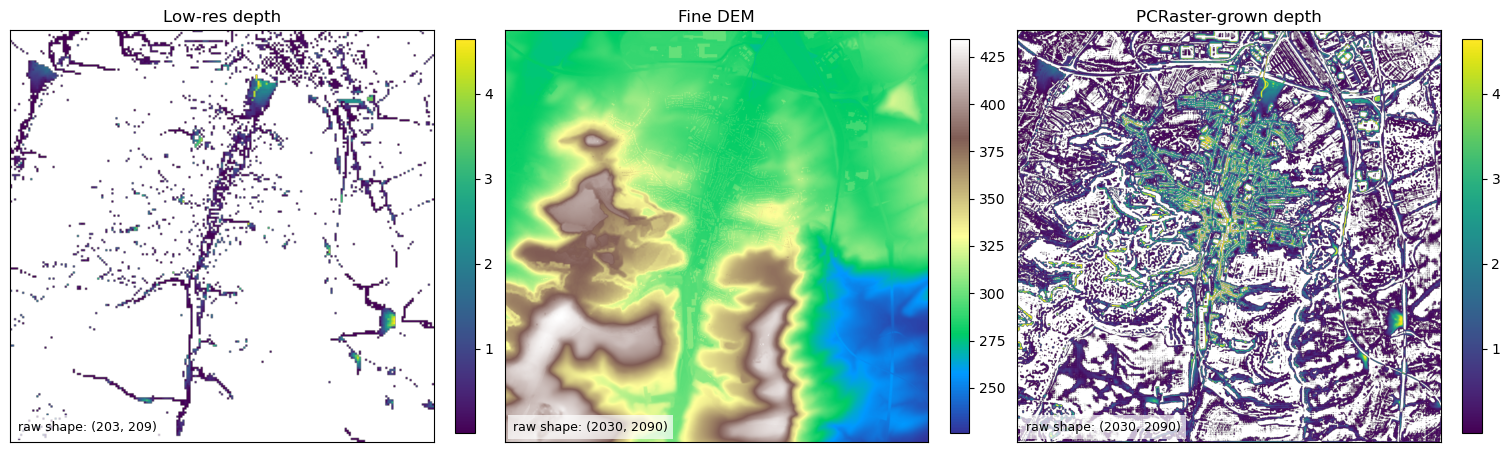

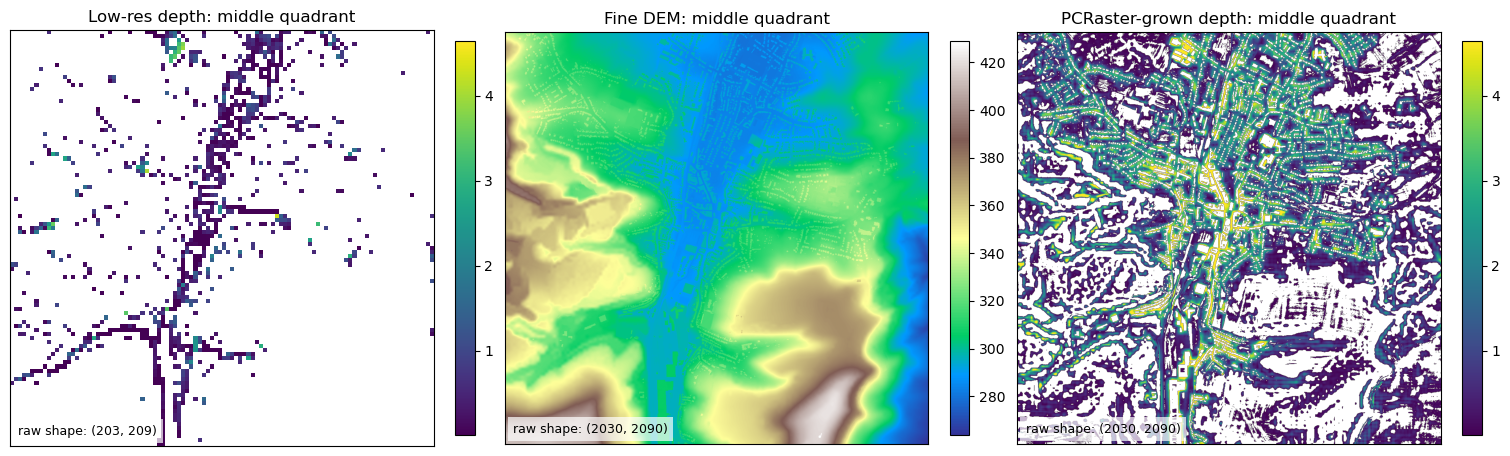

In [11]:
# Step 04: keep plotting simple and direct.
# The goal is just to sanity-check the data flow and the PCRaster growth result.
# Mask zero-depth cells so dry areas render consistently as NaN across the depth panels.

coarse_depth_plot = np.where(coarse_depth > 0.0, coarse_depth, np.nan)
result_depth_plot = np.where(result_depth > 0.0, result_depth, np.nan)

depth_vmax = np.nanmax([
    np.nanpercentile(coarse_depth_plot, 99),
    np.nanpercentile(result_depth_plot, 99),
])

coarse_row_slice = slice(coarse_depth_plot.shape[0] // 4, 3 * coarse_depth_plot.shape[0] // 4)
coarse_col_slice = slice(coarse_depth_plot.shape[1] // 4, 3 * coarse_depth_plot.shape[1] // 4)
fine_row_slice = slice(dem.shape[0] // 4, 3 * dem.shape[0] // 4)
fine_col_slice = slice(dem.shape[1] // 4, 3 * dem.shape[1] // 4)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

plot_specs = [
    (coarse_depth_plot, coarse_depth_plot.shape, "Low-res depth", DEPTH_CMAP, 0.01, depth_vmax),
    (dem, dem.shape, "Fine DEM", DEM_CMAP, None, None),
    (result_depth_plot, result_depth_plot.shape, "PCRaster-grown depth", DEPTH_CMAP, 0.01, depth_vmax),
]

for ax, (arr, raw_shape, title, cmap, vmin, vmax) in zip(axes.flat, plot_specs):
    image = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(
        0.02,
        0.02,
        f"raw shape: {raw_shape}",
        transform=ax.transAxes,
        fontsize=9,
        ha="left",
        va="bottom",
        bbox={"facecolor": "white", "alpha": 0.7, "edgecolor": "none"},
    )
    plt.colorbar(image, ax=ax, shrink=0.8)

plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

zoom_plot_specs = [
    (
        coarse_depth_plot[coarse_row_slice, coarse_col_slice],
        coarse_depth_plot.shape,
        "Low-res depth: middle quadrant",
        DEPTH_CMAP,
        0.01,
        depth_vmax,
    ),
    (
        dem[fine_row_slice, fine_col_slice],
        dem.shape,
        "Fine DEM: middle quadrant",
        DEM_CMAP,
        None,
        None,
    ),
    (
        result_depth_plot[fine_row_slice, fine_col_slice],
        result_depth_plot.shape,
        "PCRaster-grown depth: middle quadrant",
        DEPTH_CMAP,
        0.01,
        depth_vmax,
    ),
]

for ax, (arr, raw_shape, title, cmap, vmin, vmax) in zip(axes.flat, zoom_plot_specs):
    image = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(
        0.02,
        0.02,
        f"raw shape: {raw_shape}",
        transform=ax.transAxes,
        fontsize=9,
        ha="left",
        va="bottom",
        bbox={"facecolor": "white", "alpha": 0.7, "edgecolor": "none"},
    )
    plt.colorbar(image, ax=ax, shrink=0.8)

plt.show()
